In [1]:
import numpy as np
import matplotlib.pyplot as plt
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.DataLoader import load_propeller_dict
import scienceplots
plt.style.use(['science', 'no-latex'])

In [2]:
prop_name, blade_dict = load_propeller_dict('APC Dicts/10x7E')[0]

params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=1,
    num_obs_times_per_rev=100,
    device='cpu',
)

propeller = Propeller(
    geometry=blade_dict,
    params=params,
    use_cuda_timing=False,
)

propeller.run_bemt(v_inf=0.0)
thrust, torque, ct, cq = propeller.compute_total_forces()

print(f'Propeller: {prop_name}')
print(f'Thrust = {thrust:.3f} N, Torque = {torque:.4f} N m')
print(f'CT = {ct:.5f}, CQ = {cq:.6f}')

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


Propeller: 10x7E
Thrust = 8.059 N, Torque = 0.1345 N m
CT = 0.11612, CQ = 0.007632


In [3]:
sol = propeller.solution_data.copy()
sol.head()

,r,dr,chord,twist,phi,alpha,Cl,Cd,u,a_prime,d_t,d_q,F,W,Re,Ma,ds,dp
0,0.027940,0.001524,0.022291,45.3524,13.713516,31.638884,0.846652,0.967638,3.907770,0.218064,0.009575,0.000306,0.956496,16.484775,24869.718926,0.048061,0.014283,0.000043
1,0.029464,0.001524,0.022967,43.8433,13.486608,30.356692,0.843054,0.913623,4.110796,0.206262,0.011234,0.000359,0.961620,17.629319,27402.569028,0.051397,0.014296,0.000046
2,0.030988,0.001524,0.023520,42.4018,13.234119,29.167681,0.838185,0.862148,4.300900,0.194752,0.012995,0.000414,0.966180,18.790366,29911.449542,0.054782,0.014451,0.000042
3,0.032512,0.001524,0.023983,41.0356,12.968461,28.067139,0.832229,0.814319,4.478297,0.183863,0.014844,0.000472,0.970236,19.959502,32397.010126,0.058191,0.014207,0.000045
4,0.034036,0.001524,0.024402,39.7404,12.703690,27.036710,0.825614,0.769074,4.649227,0.173583,0.016803,0.000533,0.973766,21.136521,34907.000070,0.061623,0.013949,0.000047


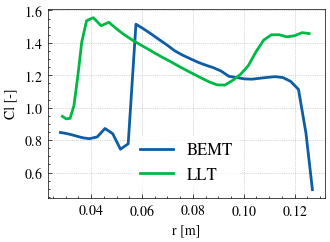

In [15]:
plt.plot(sol['r'], sol['Cl'], label='BEMT', lw=2)

# File path
file_path = 'C:/Users/Davide Pusino/Desktop/FastLLT/SVEN-main/examples/10x7E/outputs/liftDistribution_case_.dat'
data = np.loadtxt(file_path)

plt.plot(data[:, 0], data[:, 1], label='LLT', lw=2)
plt.ylabel('Cl [-]')
plt.xlabel('r [m]')
plt.legend(frameon=True, edgecolor='none', fontsize=12)
plt.grid(alpha=1, linestyle=':')
plt.tick_params(top=False, right=False, which='both')
plt.tight_layout()
plt.show()



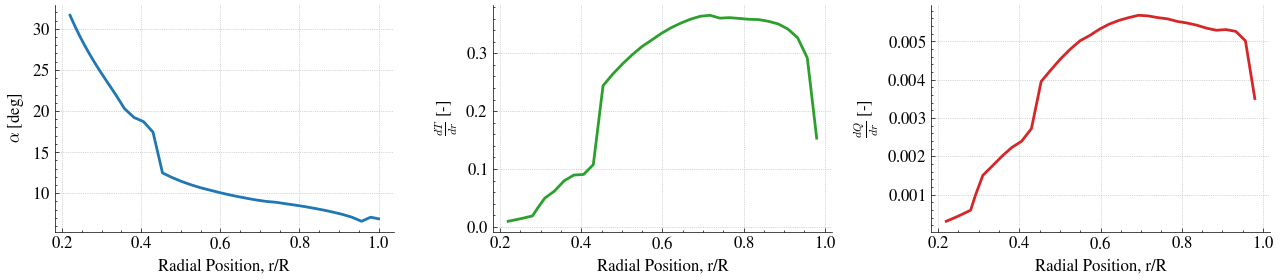

In [11]:
r = sol['r'].to_numpy()
norm_r = r / blade_dict['tip_radius']

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(norm_r, sol['alpha'].to_numpy(), linewidth=2, color='tab:blue')
axes[0].set_xlabel('Radial Position, r/R', fontsize=12)
axes[0].set_ylabel('$\\alpha$ [deg]', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=1.0)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(top=False, right=False, which='both', labelsize=12)

axes[1].plot(norm_r, sol['d_t'].to_numpy(), linewidth=2, color='tab:green')
axes[1].set_xlabel('Radial Position, r/R', fontsize=12)
axes[1].set_ylabel('$\\frac{dT}{dr}$ [-]', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=1.0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(top=False, right=False, which='both', labelsize=12)

axes[2].plot(norm_r, sol['d_q'].to_numpy(), linewidth=2, color='tab:red')
axes[2].set_xlabel('Radial Position, r/R', fontsize=12)
axes[2].set_ylabel('$\\frac{dQ}{dr}$ [-]', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=1.0)
axes[2].spines[['top', 'right']].set_visible(False)
axes[2].tick_params(top=False, right=False, which='both', labelsize=12)

plt.tight_layout()
plt.show()